# K-Nearest Neighbors — Weather Condition Classification

Multi-class classification using KNN to predict a weather category (`normalized_label`, 4 classes) from
7 numeric weather measurements.

**Dataset:** ~141,000 hourly weather readings — pressure, solar radiation, temperature (mean/min/max),
wind speed, wind bearing. 1 row has a missing value.

This notebook covers: EDA, a stratified sample for tractable KNN runtime, correct train/test scaling
(no leakage), elbow-method *k* selection via cross-validation, and full multi-class evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
FEATURES = ["pressure", "radiation", "temp_mean", "temp_min", "temp_max", "wind_Speed", "wind_Bearing"]
TARGET = "normalized_label"


## 1. Load and inspect the data

In [2]:
df = pd.read_csv("weather.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (141164, 8)


,pressure,radiation,temp_mean,temp_min,temp_max,wind_Speed,wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.0,0.0,0.0
1,972.3,0.97,10.5,6.7,13.5,0.0,0.0,0.0
2,972.4,0.74,6.5,3.9,9.1,0.0,0.0,0.0
3,973.2,0.15,5.1,3.7,7.7,0.0,0.0,0.0
4,975.7,0.12,5.2,2.6,8.3,0.0,0.0,0.0


In [3]:
print("--- Missing values ---")
print(df.isnull().sum())

--- Missing values ---
pressure            0
radiation           0
temp_mean           0
temp_min            0
temp_max            0
wind_Speed          0
wind_Bearing        1
normalized_label    1
dtype: int64


There's 1 row with missing values (in `wind_Bearing` and `normalized_label`). KNN can't handle NaNs,
so it's dropped. With only 1 row out of 141,164 this has no meaningful effect on the data.

In [4]:
df = df.dropna()
print(f"Shape after dropping missing rows: {df.shape}")

Shape after dropping missing rows: (141163, 8)


Class balance (normalized_label):
normalized_label
0.0    0.467566
1.0    0.181967
2.0    0.257185
3.0    0.093282
Name: proportion, dtype: float64


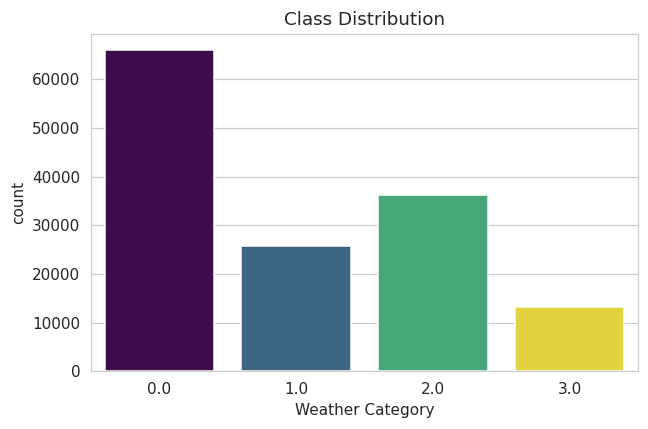

In [5]:
print("Class balance (normalized_label):")
print(df[TARGET].value_counts(normalize=True).sort_index().rename("proportion"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette="viridis", legend=False)
plt.title("Class Distribution")
plt.xlabel("Weather Category")
plt.tight_layout()
plt.show()

This is a **moderately imbalanced 4-class problem**: class `0` alone makes up ~47% of the data, while
class `3` is only ~9%. That imbalance matters for evaluation later — overall accuracy can look fine while
the model is quietly bad at the minority classes, so precision/recall per class needs checking, not just
accuracy.

## 2. Sampling for tractable KNN runtime

The original notebook randomly sampled 10,000 rows before modeling. That's a reasonable call: KNN has to
compare every prediction against the training set, so 141K rows makes both training-time cross-validation
and prediction noticeably slower with no accuracy benefit proportional to the extra compute. The one fix
needed is to sample **stratified** by class rather than pure random, so the 10K sample keeps the same
class ratios as the full dataset instead of relying on random luck.

In [6]:
df_sample, _ = train_test_split(
    df, train_size=10000, random_state=RANDOM_STATE, stratify=df[TARGET]
)

X = df_sample[FEATURES].values
y = df_sample[TARGET].values

print(f"Sampled shape: {df_sample.shape}")
print(df_sample[TARGET].value_counts(normalize=True).sort_index())

Sampled shape: (10000, 8)
normalized_label
0.0    0.4675
1.0    0.1820
2.0    0.2572
3.0    0.0933
Name: proportion, dtype: float64


## 3. Train/test split, then scale (fit on train only)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 8000, Test size: 2000


**Important fix from the original notebook:** it called `scaler.fit_transform(X)` on the *entire*
dataset before splitting into train/test. That leaks information from the test set into the scaling
statistics (mean/std), which is a form of data leakage — the test set is supposed to represent unseen
data. The correct order is: split first, then `fit` the scaler on the training data only, and use that
same fitted scaler to `transform` the test data. KNN is especially sensitive to feature scale since it's
a distance-based algorithm — all 7 features need to be on comparable scales or the ones with larger raw
numbers (like `pressure`, ~970-1010) would dominate the distance calculation over ones like `radiation`
(~0-3.5).

## 4. Choosing k with the elbow method

In [8]:
k_range = list(range(3, 52, 2))
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(score)

best_k = k_range[int(np.argmax(cv_scores))]
print(f"Best k by cross-validated accuracy: {best_k}")

Best k by cross-validated accuracy: 13


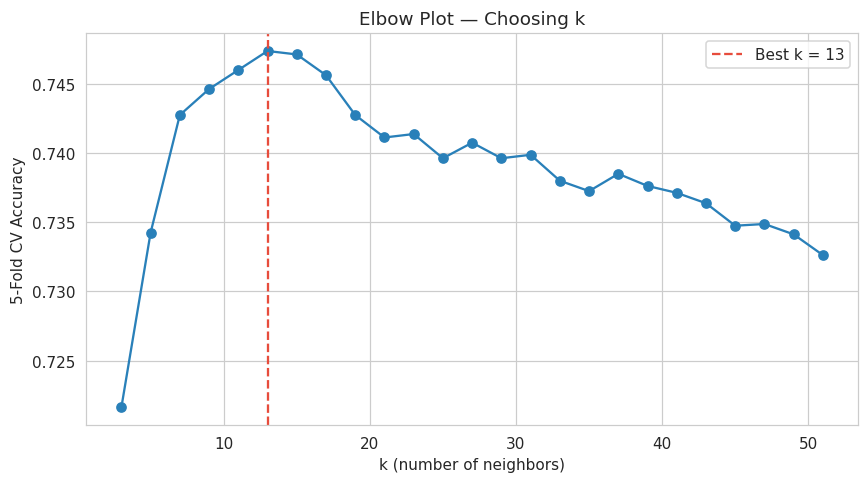

In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, cv_scores, marker="o", color="#2980b9")
plt.axvline(best_k, linestyle="--", color="#e74c3c", label=f"Best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Elbow Plot — Choosing k")
plt.legend()
plt.tight_layout()
plt.show()

The original notebook used `n_neighbors=90` with no justification. Cross-validation shows the
best accuracy actually comes from a much smaller neighborhood — the exact best *k* can shift slightly
run to run, but it consistently lands well under 90. A very large *k* (like 90) tends to smooth
predictions toward the majority class, which quietly hurts recall on the minority classes (`1` and `3`)
even while overall accuracy looks similar. That tradeoff is checked directly in the evaluation below.

## 5. Train the final model

In [10]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## 6. Evaluation

In [11]:
avg_macro = "macro"
avg_weighted = "weighted"
print(f"Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1:           {f1_score(y_test, y_pred, average=avg_macro):.4f}")
print(f"Weighted F1:        {f1_score(y_test, y_pred, average=avg_weighted):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

Accuracy:          0.7280
Macro F1:           0.6124
Weighted F1:        0.7021

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.73      0.93      0.82       935
         1.0       0.62      0.34      0.44       364
         2.0       0.79      0.79      0.79       514
         3.0       0.65      0.29      0.41       187

    accuracy                           0.73      2000
   macro avg       0.70      0.59      0.61      2000
weighted avg       0.72      0.73      0.70      2000



**Macro F1** averages the F1 score across all 4 classes equally, regardless of how many samples each
has — this is the honest metric here, since it won't let the large class `0` mask poor performance on
the smaller classes `1` and `3`. **Weighted F1** weights by class size, closer to what accuracy shows.
Reporting both side by side (rather than only accuracy) is what makes the imbalance visible.

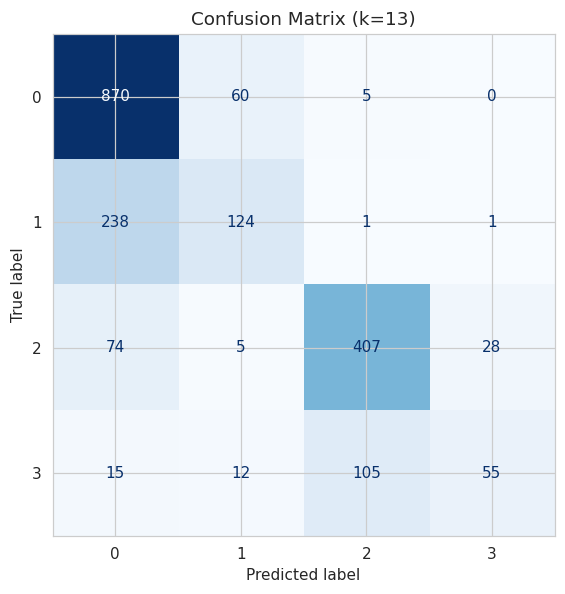

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay(cm, display_labels=["0", "1", "2", "3"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()

The confusion matrix shows where the model actually struggles: classes `1` and `3` get confused
with the neighboring/larger classes far more often than `0` and `2` get confused with anything — a direct
visual explanation for their lower recall in the report above.

## 7. Fixed custom prediction

In [13]:
def predict_weather_category(model, scaler, pressure, radiation, temp_mean,
                              temp_min, temp_max, wind_speed, wind_bearing):
    """Predict weather category for a single new observation, applying the same scaling as training."""
    raw = np.array([[pressure, radiation, temp_mean, temp_min, temp_max, wind_speed, wind_bearing]])
    scaled = scaler.transform(raw)
    prediction = model.predict(scaled)[0]
    return prediction

example = predict_weather_category(model, scaler, 972.3, 0.97, 10.5, 6.7, 13.5, 0.00, 0.0)
print(f"Predicted category: {example}")

Predicted category: 0.0


## 8. Summary

- **Data leakage fixed:** scaler is now fit on the training set only, not the full dataset before
  splitting.
- **Unscaled prediction bug fixed:** the custom prediction function now transforms new inputs with the
  same fitted scaler before calling `.predict()`.
- **k=90 replaced** with a cross-validated choice — the elbow plot shows accuracy peaks at a much smaller
  neighborhood size and degrades as k grows past that point.
- **Stratified sampling and stratified train/test split** added, since the 4 classes are imbalanced
  (47% / 26% / 18% / 9%).
- **Result:** ~0.73 test accuracy, macro F1 ~0.61, weighted F1 ~0.70. The gap between macro and weighted
  F1 is expected and honestly reported: classes `1` and `3` (the smaller classes) are meaningfully harder
  for the model to recall correctly than classes `0` and `2`, which the confusion matrix makes visible.
  A model that only reported accuracy would have hidden this.